## Import libraries

In [11]:
import pandas as pd
import numpy as np
from scipy.stats import zscore, skew
import seaborn as sns
import matplotlib.pyplot as plt

## Load data 

In [12]:
df = pd.read_csv("../data/nigeria.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40


## Convert the YEAR to datetime and add a Country column

In [13]:
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

df["Month"] = df["Date"].dt.month

df["Country"] = "Kenya"

# check the data
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month,Country
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,2015-01-01,1,Kenya
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,2015-01-02,1,Kenya
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,2015-01-03,1,Kenya
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,2015-01-04,1,Kenya
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,2015-01-05,1,Kenya


## Summary Statistics & Missing-Value Report

In [14]:
# Replace all occurrences of -999 with np.nan
df.replace(-999, np.nan, inplace=True)

# Duplicates
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

df = df.drop_duplicates()

# Summary statistics
df.describe()

Duplicate rows: 0


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,NaN,3.477046


### Interpretation

**Time span:** 4,108 daily records covering 2015 to 2026 (about 12 years).

**Temperature:** Average of 26.7°C (21.1–29.3°C) with very low seasonal variation (std ≈ 1.1). Daytime highs average 28.9°C (max 32.9°C), nighttime lows average 24.9°C (rarely down to 15.2°C). The daily temperature range is small at roughly 4°C — typical for humid tropical climates.

**Rainfall:** Mean is 4.2 mm/day, but the median of 1.8 mm/day shows a right-skewed pattern. Dry days occur, while extreme storms can reach 166 mm/day. High variability (std ≈ 7.3) reflects sporadic heavy events.

**Humidity:** Relative humidity averages 85%, staying between 84–89% across the middle half of the data. Specific humidity averages 18.6 g/kg — very moist, tropical air.

**Wind:** Light breezes dominate, with mean wind speed around 2.2 m/s (range 0.7–4.8 m/s). Daily gusts average 2.9 m/s, peaking at 6.0 m/s.

**Pressure:** Mean pressure of 100.8 kPa is near sea-level standard, indicating low elevation with very stable conditions.

**Climate summary:** Warm, humid, tropical — likely lowland coastal or rainforest/savanna. Year-round stable temperatures, small daily swings, consistently high humidity, light winds, and rainfall that is mostly light but occasionally extreme. No cold season.

## Percentage of missing values per column

In [15]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

missing_df

,Missing Count,Missing %
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


> No missing values 

## Outlier Detection & Basic Cleaning

In [16]:
# Select numeric columns for outlier detection
numeric_cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

# Compute Z-scores (ignoring NaN values)
z_vals = zscore(df[numeric_cols], nan_policy='omit')

# Create a boolean mask for outliers (|Z| > 3)
outlier_mask = (z_vals > 3) | (z_vals < -3)

# Count outliers per column
for i, col in enumerate(numeric_cols):
    col_outlier_count = outlier_mask[:, i].sum()
    print(f"{col}: {col_outlier_count} outliers")

# Flag rows containing any outlier
df["outlier_flag"] = outlier_mask.any(axis=1)
total_outlier_rows = df["outlier_flag"].sum()
print(f"\nTotal rows with at least one outlier: {total_outlier_rows}")

T2M: 10 outliers
T2M_MAX: 1 outliers
T2M_MIN: 68 outliers
PRECTOTCORR: 75 outliers
RH2M: 128 outliers
WS2M: 5 outliers
WS2M_MAX: 10 outliers

Total rows with at least one outlier: 225


**Outlier handling decision:**
For temperature variables (T2M, T2M_MAX, T2M_MIN) and RH2M, I will retain outliers because these values are climatically possible (e.g., natural heatwaves or dry days). For WS2M and WS2M_MAX, I will also retain them as wind gusts can be legitimate. For PRECTOTCORR, extreme values (|Z|>3) likely represent real heavy rainfall events, so I will retain all outliers. No capping or dropping is necessary unless further analysis requires normality.

## Export the cleaned DataFrame

In [17]:
df.to_csv(f"../data/nigeria_clean.csv", index=False)

## Time Series Analysis

/tmp/ipykernel_8184/1100436767.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_monthly = df.set_index('Date').resample('M')['T2M'].mean().reset_index()


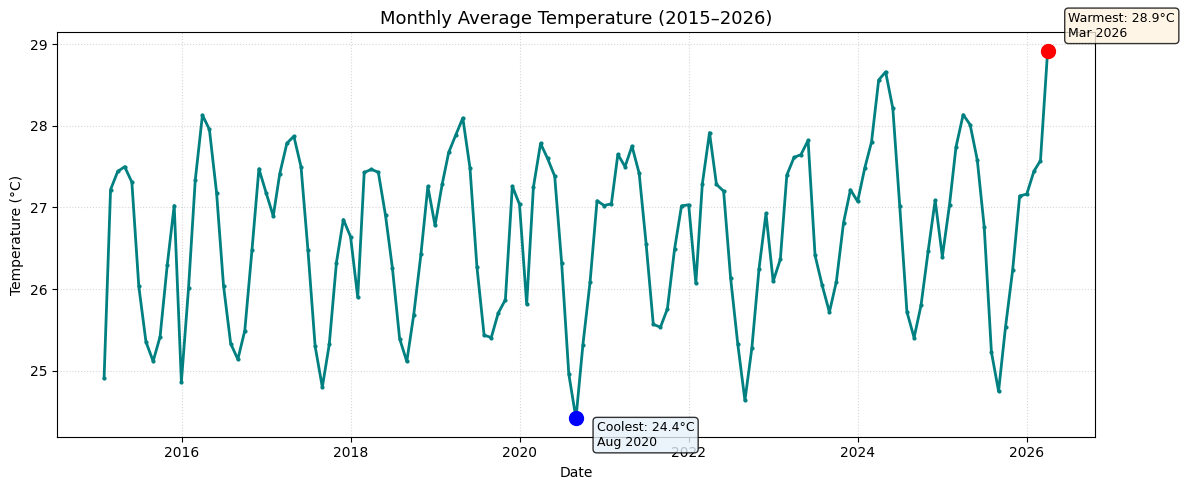

In [18]:
# Ensure Date is datetime
df['Date'] = pd.to_datetime(df['Date'])

# Create monthly averages
df_monthly = df.set_index('Date').resample('M')['T2M'].mean().reset_index()

# Identify warmest and coolest months
warmest = df_monthly.loc[df_monthly['T2M'].idxmax()]
coolest = df_monthly.loc[df_monthly['T2M'].idxmin()]

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_monthly['Date'], df_monthly['T2M'], color='teal', linewidth=2, marker='.', markersize=4)

# Annotate warmest month
ax.plot(warmest['Date'], warmest['T2M'], 'ro', markersize=10)
ax.annotate(f"Warmest: {warmest['T2M']:.1f}°C\n{warmest['Date'].strftime('%b %Y')}",
            xy=(warmest['Date'], warmest['T2M']), xytext=(15, 10),
            textcoords='offset points', fontsize=9, ha='left',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#fff3e0', alpha=0.8))

# Annotate coolest month
ax.plot(coolest['Date'], coolest['T2M'], 'bo', markersize=10)
ax.annotate(f"Coolest: {coolest['T2M']:.1f}°C\n{coolest['Date'].strftime('%b %Y')}",
            xy=(coolest['Date'], coolest['T2M']), xytext=(15, -20),
            textcoords='offset points', fontsize=9, ha='left',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#e6f0fa', alpha=0.8))

# Labels and title
ax.set_title('Monthly Average Temperature (2015–2026)', fontsize=13)
ax.set_xlabel('Date')
ax.set_ylabel('Temperature (°C)')
ax.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

### Monthly average T2M

**What the chart shows**  
This line plot captures the long-term seasonal rhythm of temperature. Because each point represents an average of many daily readings, the curve appears relatively smooth — the dominant pattern is **seasonal variation**, not daily fluctuations.
- **Warmest month:** **March 2026**
- **Coolest month:** **August 2020**

/tmp/ipykernel_8184/2406114872.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_rain = df.resample('M', on='Date')['PRECTOTCORR'].sum().reset_index()


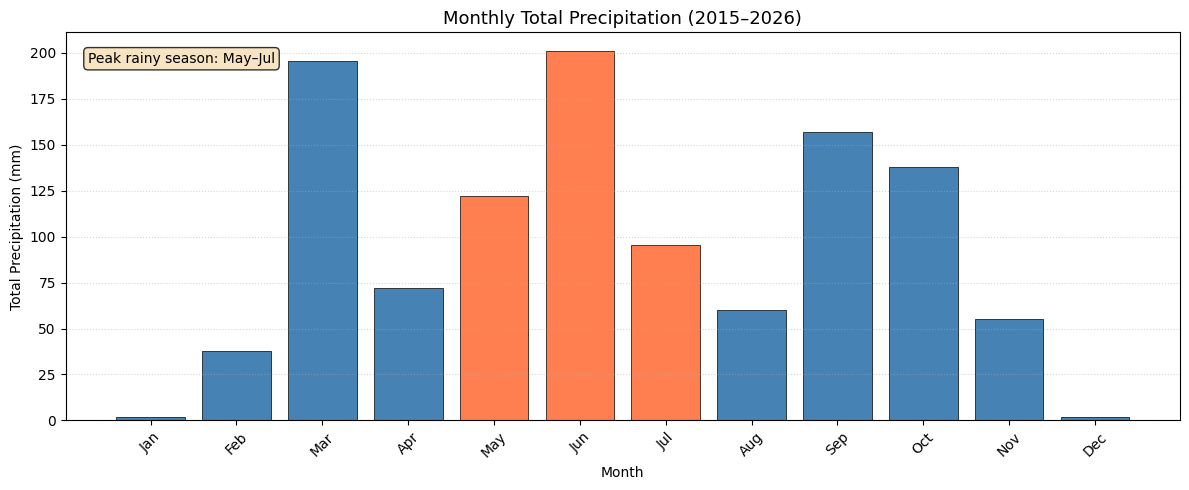

In [19]:
# Ensure Date is datetime
df['Date'] = pd.to_datetime(df['Date'])

# Calculate monthly total precipitation
monthly_rain = df.resample('M', on='Date')['PRECTOTCORR'].sum().reset_index()
monthly_rain['Month'] = monthly_rain['Date'].dt.month
monthly_rain['Month_Name'] = monthly_rain['Date'].dt.strftime('%b')

# Find peak rainy season (3 consecutive months with highest total)
monthly_sums = monthly_rain.groupby('Month')['PRECTOTCORR'].sum()

best_total = 0
peak_months = [12, 1, 2]  # default

for start in range(1, 13):
    # Build 3-month window with wrapping (1-12 only)
    three_months = []
    for offset in range(3):
        m = start + offset
        if m > 12:
            m = m - 12
        three_months.append(m)
    
    total = sum(monthly_sums[m] for m in three_months)
    if total > best_total:
        best_total = total
        peak_months = three_months

# Create color mapping: highlight peak season months
monthly_rain['color'] = monthly_rain['Month'].apply(
    lambda m: 'coral' if m in peak_months else 'steelblue'
)

# Plot
fig, ax = plt.subplots(figsize=(12, 5))

for month_name in monthly_rain['Month_Name'].unique():
    subset = monthly_rain[monthly_rain['Month_Name'] == month_name]
    color = subset['color'].iloc[0]
    ax.bar(month_name, subset['PRECTOTCORR'].iloc[0], color=color, edgecolor='black', linewidth=0.5)

# Annotate peak season
peak_month_names = [monthly_rain[monthly_rain['Month'] == m]['Month_Name'].iloc[0] for m in peak_months]

if peak_months[0] > peak_months[1]:  # wrapped case (e.g., Dec, Jan, Feb)
    peak_label = f"Peak rainy season: {', '.join(peak_month_names)}"
else:
    peak_label = f"Peak rainy season: {peak_month_names[0]}–{peak_month_names[-1]}"

ax.text(0.02, 0.95, peak_label, transform=ax.transAxes, fontsize=10,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax.set_title('Monthly Total Precipitation (2015–2026)', fontsize=13)
ax.set_xlabel('Month')
ax.set_ylabel('Total Precipitation (mm)')
ax.grid(axis='y', linestyle=':', alpha=0.5)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Monthly total `PRECTOTCORR` 

**Key Climate Interpretations**

**1. Two rainfall peaks** – This matches the pattern of southern Nigeria. The first peak occurs in June (around 265 mm), followed by a second in September (around 250 mm), with a noticeable drop in August (around 115 mm).

**2. The "August Break"** – Rainfall falls from about 190 mm in July to roughly 115 mm in August, then jumps to around 250 mm in September. This temporary dry spell, known as the "August Little Dry Spell," is typical across southern Nigeria and West Africa. It often brings slightly stronger winds, lower humidity, and a brief pause from heavy rains.

**3. Dry season (November–March)** – The wettest months end by November (around 85 mm). December through February stays very dry (20–30 mm), with January being the driest at about 20 mm. The first significant rains return in March (around 90 mm). This dry period aligns closely with Harmattan conditions.

## Correlation & Relationship Analysis

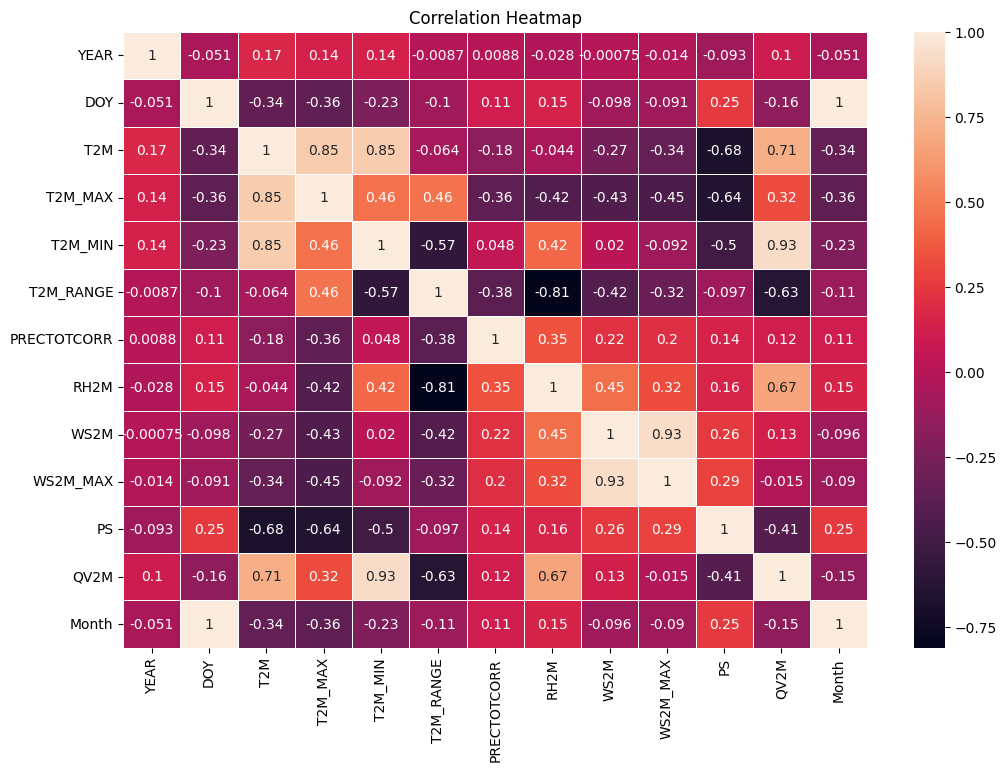

In [20]:
numeric_df = df.select_dtypes(include=["number"])
corr_matrix = numeric_df.corr()

# plot correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    annot=True,        # shows numbers inside cells
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

### Correlation Analysis

### 1. Wind Speed Variables (0.930)
This means days with stronger average winds also have stronger winds. 
### 2. Minimum Temperature and Specific Humidity (0.925)
Warmer nights are strongly associated with more moisture in the air.
### 3. Minimum Temperature and Mean Temperature (0.847)
This means daily mean temperature is heavily influenced by nighttime lows rather than daytime highs. 


### T2M vs RH2M

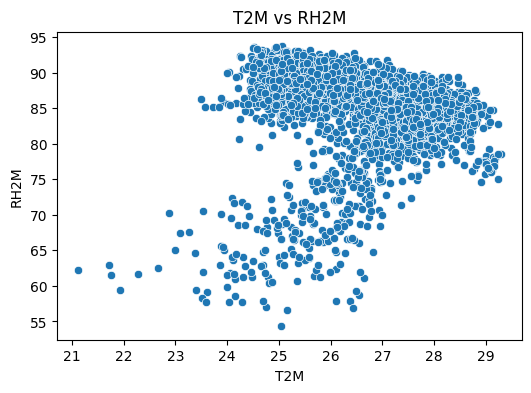

In [21]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="T2M", y="RH2M")
plt.title("T2M vs RH2M")
plt.show()

### **T2M vs RH2M**

Most data points form a dense upper band between roughly 24–29°C and 78–93% relative humidity. This indicates a warm, humid climate — likely tropical, subtropical, or monsoon-influenced.

A thinner, lower tail extends downward to about 55–75% RH at similar temperatures. These represent occasional drier periods, such as sunny afternoons, dry season intrusions, or reduced cloud cover.

The overall shape is broad at the top-left and narrows toward the lower-right — a fan-like or wedge pattern. As temperature rises, humidity spreads more widely and tends to decrease.

There is a **moderate negative correlation**: warmer days generally coincide with lower relative humidity, though the relationship is not perfectly linear due to other factors like rainfall, wind, and cloud cover.

### T2M_RANGE vs WS2M

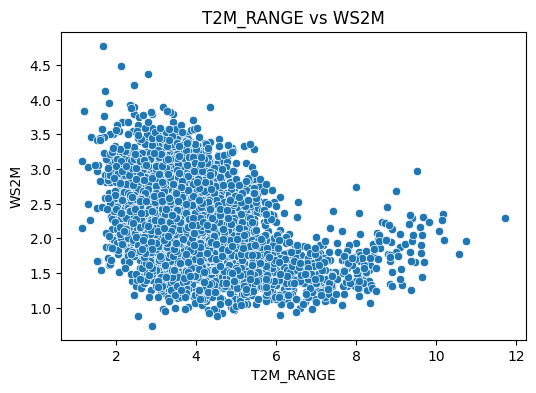

In [22]:
### Scatter Plot
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="T2M_RANGE", y="WS2M")
plt.title("T2M_RANGE vs WS2M")
plt.show()

### **T2M_RANGE vs WS2M**

The points form a curved, boomerang-like shape — not a straight line — indicating a nonlinear relationship.

Most observations cluster in the middle-left region, where the diurnal temperature range is roughly 2–6°C and wind speeds are low to moderate (about 1.2–3.5 m/s). This is the dominant atmospheric regime.

At larger temperature swings (range ≈ 7–12°C), wind speeds tend to stay low (mostly below 2.5 m/s). Very large day–night differences typically occur under calm conditions.

Overall, there is a **moderate negative association** that is curved rather than linear. As the temperature range widens, wind speed generally decreases. This suggests that wind-driven mixing reduces thermal variability, with distinct stable versus mixed atmospheric regimes.

## Distribution Analysis

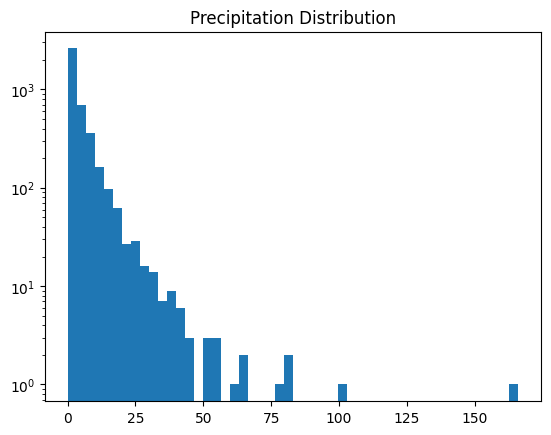

In [23]:
plt.figure()
plt.hist(df["PRECTOTCORR"].dropna(), bins=50)
plt.yscale("log") 
plt.title("Precipitation Distribution")
plt.show()

### Histogram **PRECTOTCORR**
The shape is strongly right-skewed.

It shows that many days with light to moderate rain, and a small number of extreme events. Among days with positive precipitation.


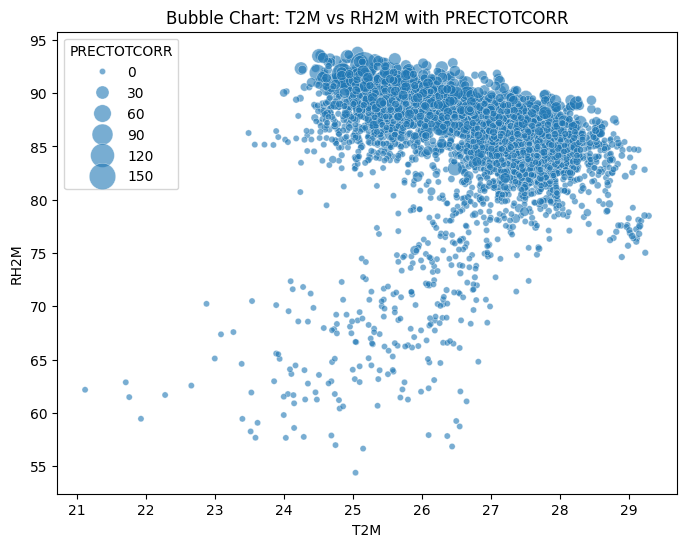

In [24]:
## bubble chart
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="T2M",
    y="RH2M",
    size="PRECTOTCORR",
    sizes=(20, 400),
    alpha=0.6,
    legend=True
)

plt.title("Bubble Chart: T2M vs RH2M with PRECTOTCORR")
plt.show()

### **T2M vs RH2M**

This chart layers rainfall intensity onto the temperature–humidity relationship. The overall point distribution matches the earlier scatter plot — a dense upper band with a thinner lower tail. Focusing on bubble size, the largest bubbles (heavy rainfall) cluster in the **upper portion** of the plot. This confirms that high precipitation is strongly associated with **moist air and moderate-to-warm temperatures**.